In [ ]:
# 1. Kết nối với Drive
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)


Mounted at /content/gdrive


In [ ]:
# 1. CÀI ĐẶT MÔI TRƯỜNG VÀ THƯ VIỆN (Chỉ chạy 1 lần)
# Thêm -qq và -q để ẩn bớt log cài đặt cho gọn màn hình
!apt-get install openjdk-11-jdk-headless -qq -y
!pip install pyspark==3.5.0 findspark notebook plotly pandas matplotlib graphviz -q

# Ghi nhận Jupyter kernel
!python -m ipykernel install --user --name pyspark-env --display-name "Python (PySpark)"

# 2. IMPORT THƯ VIỆN & THIẾT LẬP BIẾN MÔI TRƯỜNG
import os
import sys
import findspark
import pyspark
import pandas as pd
import matplotlib

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/usr/local/lib/python3.12/dist-packages/pyspark"

# Khởi tạo findspark
findspark.init()

# 3. KIỂM TRA VÀ IN VERSION (Theo yêu cầu)
print("="*30)
print("THÔNG TIN MÔI TRƯỜNG & PHIÊN BẢN")
print("="*30)
print(f"Python version: {sys.version.split(' ')[0]}")
!java -version
print(f"PySpark version: {pyspark.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"JAVA_HOME = {os.environ.get('JAVA_HOME')}")
print(f"SPARK_HOME = {os.environ.get('SPARK_HOME')}")
print("="*30)

# 4. KHỞI TẠO SPARK SESSION & TEST
from pyspark.sql import SparkSession

# Gộp cấu hình offHeap vào SparkSession chính thức
spark = SparkSession.builder \
    .appName("Olist_Machine_Learning") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "10g") \
    .getOrCreate()

print("\nĐã khởi tạo SparkSession thành công!")

# Chạy test DataFrame để đảm bảo Spark đang hoạt động tốt
df = spark.createDataFrame([(1, "hello"), (2, "world")], ["id", "text"])
df.show()

Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: using /usr/lib/jvm/jav

#  ĐỌC, LOAD FILE

In [ ]:
data_path = "/content/gdrive/MyDrive/BIGDATA/Dataset cuối kỳ/Dataset cuối kỳ/cleaned_master_data.parquet"

# Lúc này biến 'spark' đã tồn tại nên sẽ không bị lỗi nữa
df_master = spark.read.parquet(data_path)

# Kiểm tra xem dữ liệu đã lên chưa
df_master.show(5)

+--------------------+---------------------+--------------------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+-------------+-------------------+-----+-------------+------------------+------------+--------------------+-------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+-----------------------------+----------------------+-------------------+------------+---------------------------+-------------------+-------------------+--------------------+-----------------+
|           seller_id|product_category_name|          product_id|            order_id|    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, datediff, when, mean, count

# Tạo thêm các biến thời gian và trễ hẹn (Feature Engineering)
df_master = df_master.withColumn("delivery_days",
                                 datediff(col("order_delivered_customer_date"), col("order_purchase_timestamp")))

df_master = df_master.withColumn("is_late",
                                 when(col("order_delivered_customer_date") > col("order_estimated_delivery_date"), "Late")
                                 .otherwise("On Time"))

# Thiết lập phong cách chung cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

/tmp/ipykernel_20266/1272856242.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="review_score", y="count", data=score_dist, palette="Blues_d")


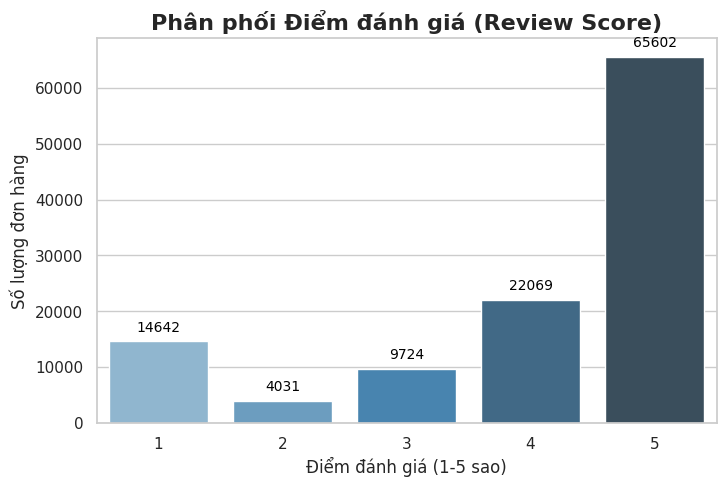

In [ ]:
plt.figure(figsize=(8, 5))

# Dùng PySpark để đếm số lượng, sau đó chuyển sang Pandas
score_dist = df_master.groupBy("review_score").count().orderBy("review_score").toPandas()

# Vẽ biểu đồ Bar Chart
ax = sns.barplot(x="review_score", y="count", data=score_dist, palette="Blues_d")
plt.title("Phân phối Điểm đánh giá (Review Score)", fontsize=16, fontweight='bold')
plt.xlabel("Điểm đánh giá (1-5 sao)", fontsize=12)
plt.ylabel("Số lượng đơn hàng", fontsize=12)

# Hiển thị con số cụ thể trên từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

/tmp/ipykernel_20266/71755839.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_score", y="count", data=score_dist, palette=colors, ax=ax1, edgecolor=".2")


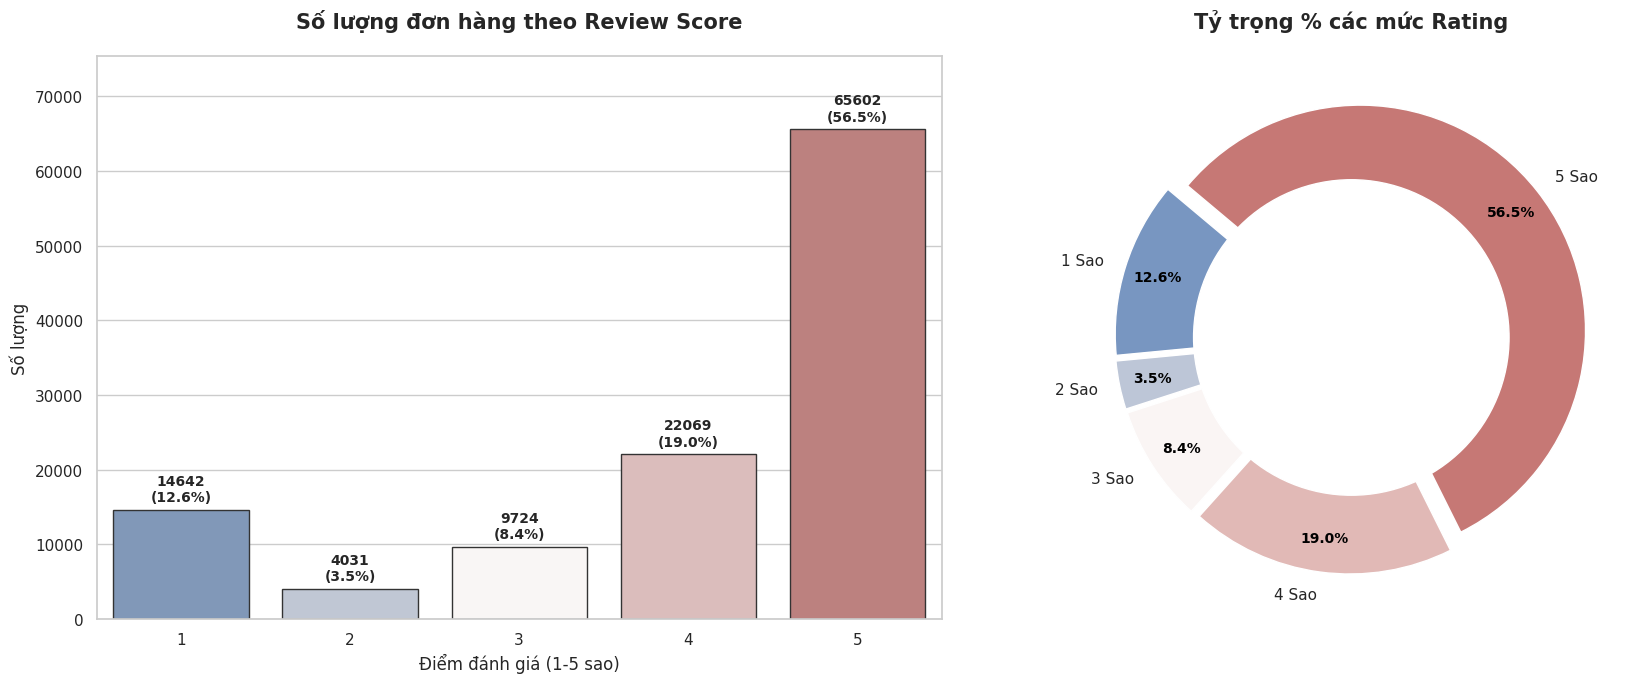

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. TÍNH TOÁN DỮ LIỆU TỪ PYSPARK
# Lấy dữ liệu và tính thêm cột tỷ lệ % ngay trên Pandas để vẽ cho nhanh
score_dist = df_master.groupBy("review_score").count().orderBy("review_score").toPandas()
score_dist['pct'] = (score_dist['count'] / score_dist['count'].sum() * 100).round(1)

# 2. THIẾT LẬP GIAO DIỆN (Style)
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors = sns.color_palette("vlag", len(score_dist)) # Palette màu hiện đại

# --- AX1: BIỂU ĐỒ CỘT (BAR CHART) ---
sns.barplot(x="review_score", y="count", data=score_dist, palette=colors, ax=ax1, edgecolor=".2")
ax1.set_title("Số lượng đơn hàng theo Review Score", fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel("Điểm đánh giá (1-5 sao)", fontsize=12)
ax1.set_ylabel("Số lượng", fontsize=12)

# Thêm nhãn số lượng và % trên đầu cột
for i, p in enumerate(ax1.patches):
    count = int(score_dist.iloc[i]['count'])
    pct = score_dist.iloc[i]['pct']
    ax1.annotate(f'{count}\n({pct}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 fontsize=10, fontweight='bold',
                 xytext=(0, 15), textcoords='offset points')

# Nới rộng trục y một chút để không bị dính nhãn vào cạnh trên
ax1.set_ylim(0, score_dist['count'].max() * 1.15)

# --- AX2: BIỂU ĐỒ TRÒN KHUYẾT (DONUT CHART) ---
# Vẽ biểu đồ tròn trước
wedges, texts, autotexts = ax2.pie(
    score_dist['count'],
    labels=[f"{int(s)} Sao" for s in score_dist['review_score']],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05] * len(score_dist) # Tạo khoảng cách giữa các miếng
)

# Vẽ một hình tròn trắng ở giữa để tạo hiệu ứng Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax2.add_artist(centre_circle)

# Chỉnh font cho phần trăm
plt.setp(autotexts, size=10, weight="bold", color="black")
ax2.set_title("Tỷ trọng % các mức Rating", fontsize=15, fontweight='bold', pad=20)

# 3. HOÀN THIỆN
plt.tight_layout()
plt.show()

/tmp/ipykernel_492/3737430482.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="review_score", y="delivery_days", data=pdf_delivery, palette="coolwarm")


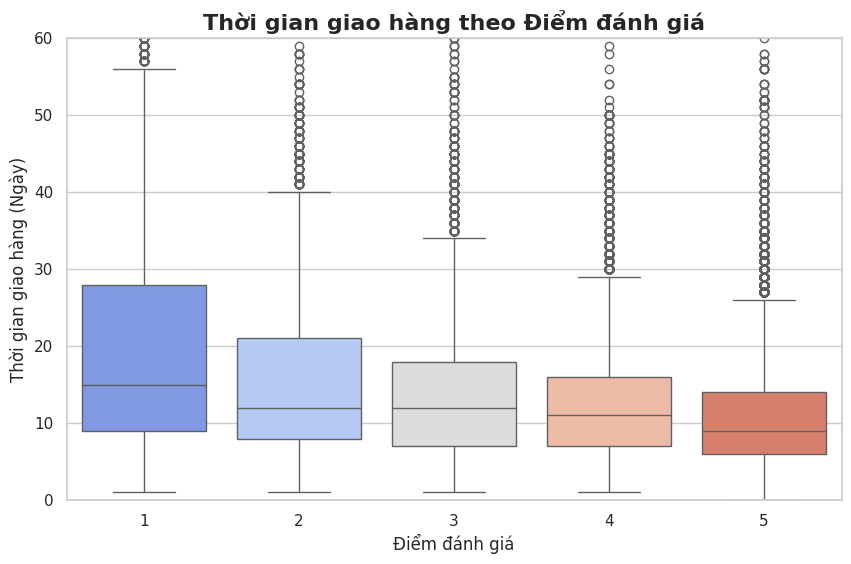

In [ ]:
plt.figure(figsize=(10, 6))

# Chỉ select 2 cột cần thiết, bỏ các dòng Null và đưa về Pandas
pdf_delivery = df_master.select("review_score", "delivery_days").dropna().toPandas()

# Vẽ Boxplot
sns.boxplot(x="review_score", y="delivery_days", data=pdf_delivery, palette="coolwarm")
plt.title("Thời gian giao hàng theo Điểm đánh giá", fontsize=16, fontweight='bold')
plt.xlabel("Điểm đánh giá", fontsize=12)
plt.ylabel("Thời gian giao hàng (Ngày)", fontsize=12)

# Giới hạn trục Y (VD: 0 - 60 ngày) vì có thể có những đơn outlier mất hàng trăm ngày để giao
plt.ylim(0, 60)
plt.show()

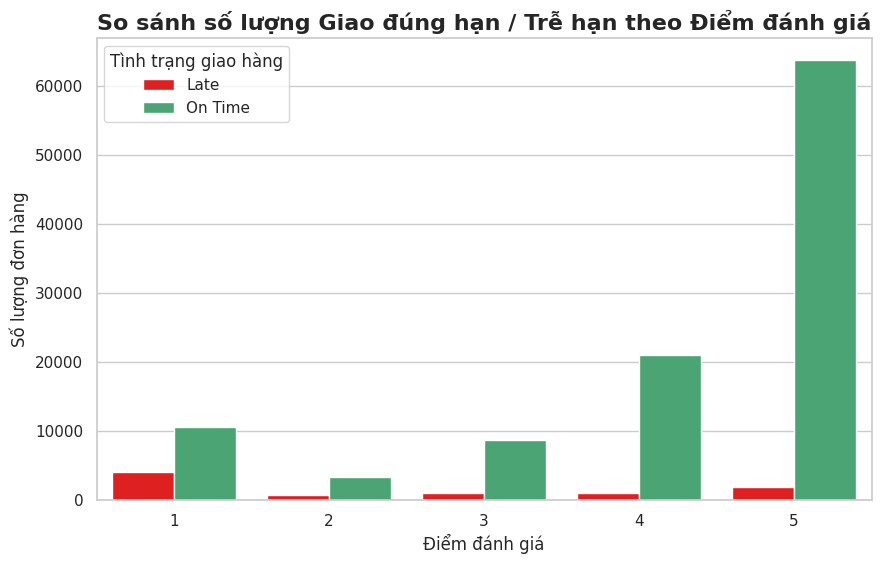

In [ ]:
plt.figure(figsize=(10, 6))

# Group by 2 biến và đếm
late_stats = df_master.groupBy("review_score", "is_late").count().toPandas()

# Vẽ biểu đồ nhóm (Grouped Bar Chart)
sns.barplot(x="review_score", y="count", hue="is_late", data=late_stats, palette={"Late": "red", "On Time": "mediumseagreen"})

plt.title("So sánh số lượng Giao đúng hạn / Trễ hạn theo Điểm đánh giá", fontsize=16, fontweight='bold')
plt.xlabel("Điểm đánh giá", fontsize=12)
plt.ylabel("Số lượng đơn hàng", fontsize=12)
plt.legend(title="Tình trạng giao hàng")

plt.show()

/tmp/ipykernel_492/3572956587.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="review_score", y="freight_value", data=pdf_freight, palette="YlOrBr")


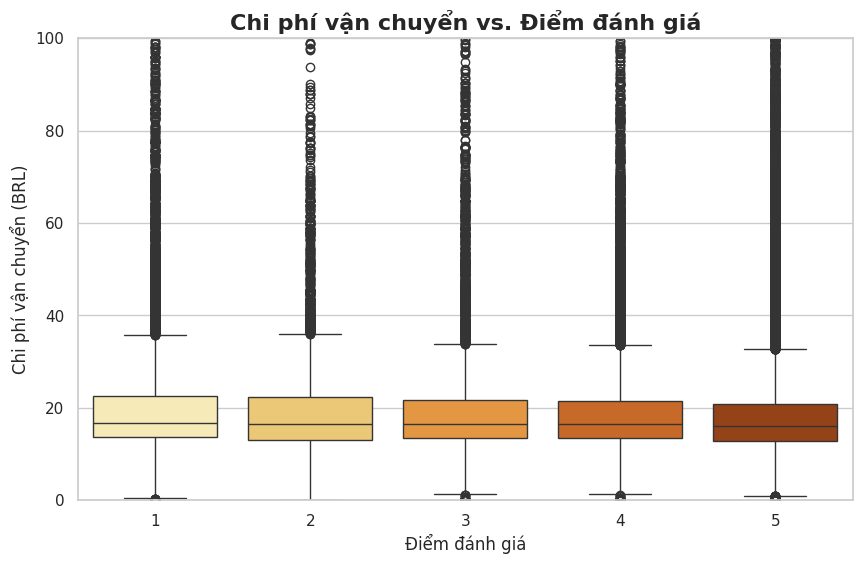

In [ ]:
plt.figure(figsize=(10, 6))

# Select dữ liệu phí vận chuyển
pdf_freight = df_master.select("review_score", "freight_value").dropna().toPandas()

# Boxplot xem phân phối phí ship
sns.boxplot(x="review_score", y="freight_value", data=pdf_freight, palette="YlOrBr")
plt.title("Chi phí vận chuyển vs. Điểm đánh giá", fontsize=16, fontweight='bold')
plt.xlabel("Điểm đánh giá", fontsize=12)
plt.ylabel("Chi phí vận chuyển (BRL)", fontsize=12)

# Cắt bớt Outlier (Các đơn phí ship khổng lồ) để biểu đồ dễ nhìn hơn
plt.ylim(0, 100)
plt.show()

/tmp/ipykernel_492/1417756230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="avg_score", y="customer_state", data=state_scores, palette="flare")


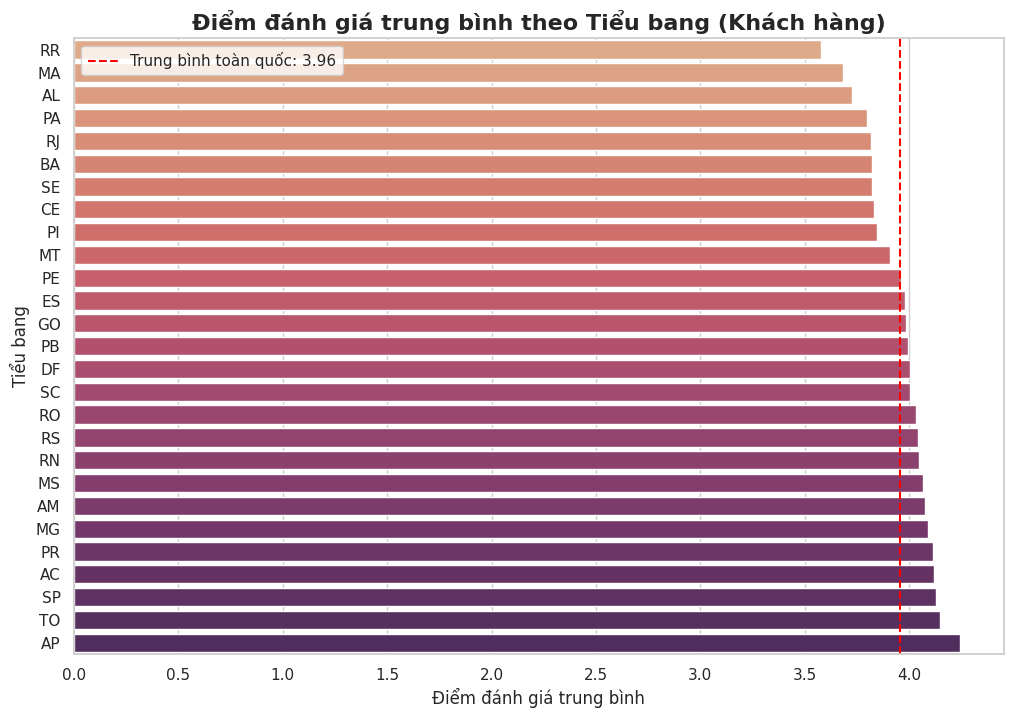

In [ ]:
plt.figure(figsize=(12, 8))

# Tính điểm đánh giá trung bình theo từng tiểu bang và sắp xếp từ thấp đến cao
state_scores = (df_master.groupBy("customer_state")
                .agg(mean("review_score").alias("avg_score"))
                .orderBy("avg_score")
                .toPandas())

# Vẽ biểu đồ cột ngang
sns.barplot(x="avg_score", y="customer_state", data=state_scores, palette="flare")

plt.title("Điểm đánh giá trung bình theo Tiểu bang (Khách hàng)", fontsize=16, fontweight='bold')
plt.xlabel("Điểm đánh giá trung bình", fontsize=12)
plt.ylabel("Tiểu bang", fontsize=12)

# Kẻ một đường gióng xem mốc điểm trung bình chung là bao nhiêu
overall_avg = state_scores['avg_score'].mean()
plt.axvline(overall_avg, color='red', linestyle='--', label=f'Trung bình toàn quốc: {overall_avg:.2f}')
plt.legend()

plt.show()

In [ ]:
from pyspark.sql.functions import col, when, length

# 1. Tạo biến 'has_comment': Kiểm tra xem bình luận có bị Null hoặc rỗng không
df_master = df_master.withColumn("has_comment",
                                 when(col("review_comment_message").isNull() | (col("review_comment_message") == ""), 0)
                                 .otherwise(1))

# 2. Tạo biến 'comment_length': Đếm số ký tự của bình luận
df_master = df_master.withColumn("comment_length",
                                 when(col("has_comment") == 1, length(col("review_comment_message")))
                                 .otherwise(0))

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline

# 1. Tiền xử lý: Fill Null bằng chuỗi rỗng
df_master = df_master.fillna({"review_comment_message": ""})

# 2. Khai báo các bước trong Pipeline NLP
# Bước 2.1: Tách từ (Tokenizer)
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="words")

# Bước 2.2: Loại bỏ từ dừng tiếng Bồ Đào Nha (StopWordsRemover)
# PySpark hỗ trợ sẵn "portuguese"
stopwords_remover = StopWordsRemover(inputCol="words",
                                     outputCol="filtered_words",
                                     stopWords=StopWordsRemover.loadDefaultStopWords("portuguese"))

# Bước 2.3: Tính tần suất từ (Term Frequency - TF)
# Giới hạn 5000 từ phổ biến nhất, từ nào xuất hiện ít nhất 5 lần mới lấy
count_vectorizer = CountVectorizer(inputCol="filtered_words",
                                   outputCol="rawFeatures",
                                   vocabSize=5000,
                                   minDF=5.0)

# Bước 2.4: Inverse Document Frequency (IDF)
idf = IDF(inputCol="rawFeatures", outputCol="tfidf_features")

# 3. Đóng gói vào Pipeline và Thực thi
nlp_pipeline = Pipeline(stages=[tokenizer, stopwords_remover, count_vectorizer, idf])

# Fit và Transform dữ liệu
nlp_model = nlp_pipeline.fit(df_master)
df_master_nlp = nlp_model.transform(df_master)

# Hiển thị kết quả xem vector sinh ra như thế nào
df_master_nlp.select("review_score", "review_comment_message", "tfidf_features").show(5, truncate=False)

+------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
|review_score|review_comment_message                                                          |tfidf_features                                                                                                                              |
+------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
|5           |Perfeito, produto entregue antes do combinado.                                  |(5000,[1,3,9,367,487],[1.9779154017734117,2.96426038857044,3.429499962364566,6.771590992613149,7.046819603993643])                          |
|4           |No Comment                            

In [ ]:
import time
import pandas as pd
from pyspark.sql.functions import col, when, udf
from pyspark.ml.linalg import VectorUDT
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (SQLTransformer, Tokenizer, StopWordsRemover, CountVectorizer,
                                IDF, StringIndexer, OneHotEncoder, VectorAssembler,
                                MaxAbsScaler, ChiSqSelector) # Dùng MaxAbsScaler cho dữ liệu thưa
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes, LinearSVC, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

print("==========================================================")
print("BƯỚC 1: CHUẨN BỊ DỮ LIỆU & CLASS WEIGHTING")
print("==========================================================")
# Điền rỗng cho comment và tạo nhãn
df_master = df_master.fillna({"review_comment_message": ""})
df_master = df_master.withColumn("label", when(col("review_score") >= 4, 1.0).otherwise(0.0))

cols_to_check = ["order_delivered_customer_date", "order_purchase_timestamp", "order_estimated_delivery_date", "freight_value", "label"]
df_master_clean = df_master.dropna(subset=cols_to_check)

print("Đang cắt phân tầng Train/Test (80/20)...")
fractions = {0.0: 0.8, 1.0: 0.8}
train_data = df_master_clean.stat.sampleBy("label", fractions, seed=42)
test_data = df_master_clean.subtract(train_data)

print("Đang tính toán trọng số cân bằng nhãn (Class Weighting)...")
total_train = train_data.count()
pos_count = train_data.filter(col("label") == 1.0).count()

balancing_ratio = pos_count / total_train
train_data = train_data.withColumn("class_weight", when(col("label") == 1.0, 1.0 - balancing_ratio).otherwise(balancing_ratio))
test_data = test_data.withColumn("class_weight", when(col("label") == 1.0, 1.0 - balancing_ratio).otherwise(balancing_ratio))

print("\n==========================================================")
print("BƯỚC 2: XÂY DỰNG BASE PIPELINE & RỬA METADATA")
print("==========================================================")
# 1. SQLTransformer
sql_trans = SQLTransformer(statement="""
    SELECT *,
           datediff(order_delivered_customer_date, order_purchase_timestamp) AS delivery_days,
           CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1.0 ELSE 0.0 END AS is_late,
           CASE WHEN review_comment_message != '' THEN 1.0 ELSE 0.0 END AS has_comment,
           length(review_comment_message) AS comment_length
    FROM __THIS__
""")

# 2. Xử lý NLP
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="words")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=StopWordsRemover.loadDefaultStopWords("portuguese"))
count_vectorizer = CountVectorizer(inputCol="filtered_words", outputCol="rawFeatures", vocabSize=5000, minDF=5.0)
idf = IDF(inputCol="rawFeatures", outputCol="tfidf_features")

# 3. Mã hóa Categorical
cat_cols = ["payment_type", "customer_state"]
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in cat_cols]

# 4. Gom cụm đặc trưng
numeric_cols = ["delivery_days", "is_late", "has_comment", "comment_length", "freight_value", "product_photos_qty", "product_weight_g"]
assembler_inputs = ["tfidf_features"] + [f"{c}_ohe" for c in cat_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="assembled_features", handleInvalid="skip")

# 5. 🌟 FIX LỖI HIỆU SUẤT TẠI ĐÂY
# Dùng MaxAbsScaler để bảo toàn ma trận thưa TF-IDF
scaler = MaxAbsScaler(inputCol="assembled_features", outputCol="scaled_features")
# Tăng lên 2000 features để model giữ lại đủ từ vựng phân loại
selector = ChiSqSelector(numTopFeatures=2000, featuresCol="scaled_features", outputCol="features", labelCol="label")

# Gộp tất cả vào Base Pipeline
base_stages = [sql_trans, tokenizer, stopwords_remover, count_vectorizer, idf] + indexers + encoders + [assembler, scaler, selector]
base_pipeline = Pipeline(stages=base_stages)

print("⏳ Đang huấn luyện Base Pipeline (Chạy 1 lần duy nhất)...")
base_model = base_pipeline.fit(train_data)
train_ready_raw = base_model.transform(train_data)
test_ready_raw = base_model.transform(test_data)

# 🌟 FIX LỖI RANDOM FOREST/GBT
print("🧹 Đang dọn dẹp Metadata để chuẩn bị cho các mô hình dạng Cây...")
clear_meta_udf = udf(lambda v: v, VectorUDT())

train_ready = train_ready_raw.withColumn("features", clear_meta_udf(col("features"))).cache()
test_ready = test_ready_raw.withColumn("features", clear_meta_udf(col("features"))).cache()

print("\n==========================================================")
print("BƯỚC 3: HUẤN LUYỆN 5 MÔ HÌNH (CROSS-VALIDATION 5-FOLDS)")
print("==========================================================")
models_info = {
    "Logistic Regression": {
        "model": LogisticRegression(featuresCol="features", labelCol="label", weightCol="class_weight", maxIter=20),
        "grid": ParamGridBuilder().addGrid(LogisticRegression.regParam, [0.01, 0.1]).build()
    },
    "Random Forest": {
        "model": RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="class_weight", seed=42),
        "grid": ParamGridBuilder().addGrid(RandomForestClassifier.maxDepth, [5, 10]).addGrid(RandomForestClassifier.numTrees, [20, 50]).build()
    },
    "Naive Bayes": {
        "model": NaiveBayes(featuresCol="features", labelCol="label", weightCol="class_weight"),
        "grid": ParamGridBuilder().addGrid(NaiveBayes.smoothing, [0.1, 1.0]).build()
    },
    "LinearSVC": {
        "model": LinearSVC(featuresCol="features", labelCol="label", weightCol="class_weight", maxIter=20),
        "grid": ParamGridBuilder().addGrid(LinearSVC.regParam, [0.01, 0.1]).build()
    },
    "GBTClassifier": {
        "model": GBTClassifier(featuresCol="features", labelCol="label", weightCol="class_weight", seed=42),
        "grid": ParamGridBuilder().addGrid(GBTClassifier.maxDepth, [5]).addGrid(GBTClassifier.maxIter, [20]).build()
    }
}

def calculate_metrics(predictions):
    multi_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    bin_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

    acc = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "accuracy"})
    p0 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "precisionByLabel", multi_evaluator.metricLabel: 0.0})
    p1 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "precisionByLabel", multi_evaluator.metricLabel: 1.0})
    macro_precision = (p0 + p1) / 2.0 if p0 and p1 else 0.0

    r0 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "recallByLabel", multi_evaluator.metricLabel: 0.0})
    r1 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "recallByLabel", multi_evaluator.metricLabel: 1.0})
    macro_recall = (r0 + r1) / 2.0 if r0 and r1 else 0.0

    f1_0 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "fMeasureByLabel", multi_evaluator.metricLabel: 0.0})
    f1_1 = multi_evaluator.evaluate(predictions, {multi_evaluator.metricName: "fMeasureByLabel", multi_evaluator.metricLabel: 1.0})
    macro_f1 = (f1_0 + f1_1) / 2.0 if f1_0 and f1_1 else 0.0
    auc = bin_evaluator.evaluate(predictions)

    return acc, macro_precision, macro_recall, macro_f1, auc

results_list = []
best_models_dict = {}
evaluator_cv = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

for model_name, info in models_info.items():
    print(f"🚀 Đang huấn luyện: {model_name}...")
    cv = CrossValidator(estimator=info["model"], estimatorParamMaps=info["grid"], evaluator=evaluator_cv, numFolds=5, seed=42)

    start_time = time.time()
    cv_model = cv.fit(train_ready)
    train_time = time.time() - start_time

    best_models_dict[model_name] = cv_model.bestModel

    predictions = cv_model.transform(test_ready)
    acc, p_mac, r_mac, f1_mac, auc = calculate_metrics(predictions)

    results_list.append({
        "Model": model_name, "Accuracy": f"{acc*100:.2f}%", "Precision (macro)": f"{p_mac:.4f}",
        "Recall (macro)": f"{r_mac:.4f}", "F1-score (macro)": f"{f1_mac:.4f}", "AUC-ROC": f"{auc:.4f}",
        "Train time (s)": f"{train_time:.1f}s"
    })
    print(f"   ✅ Hoàn thành trong {train_time:.1f} giây!")

print("\n==========================================================")
print("BƯỚC 4: TỔNG HỢP VÀ LƯU PIPELINE CHO GRADIO (WEB UI)")
print("==========================================================")
df_results = pd.DataFrame(results_list)
df_results['AUC_numeric'] = df_results['AUC-ROC'].astype(float)

best_model_name = df_results.loc[df_results['AUC_numeric'].idxmax()]['Model']
print(f"🌟 MÔ HÌNH XUẤT SẮC NHẤT LÀ: {best_model_name}")

df_results = df_results.drop(columns=['AUC_numeric'])
try:
    display(df_results)
except NameError:
    print(df_results.to_markdown(index=False))

# 🌟 LƯU TÁCH BIỆT THÀNH 2 KHỐI CHO GRADIO
pipeline_save_path = "/content/gdrive/MyDrive/BIGDATA/gradio_base_pipeline"
model_save_path = "/content/gdrive/MyDrive/BIGDATA/gradio_best_model"

base_model.write().overwrite().save(pipeline_save_path)
best_models_dict[best_model_name].write().overwrite().save(model_save_path)

print(f"\n✅ Đã lưu Base Pipeline (NLP + Tiền xử lý) tại: {pipeline_save_path}")
print(f"✅ Đã lưu Mô hình phân loại chiến thắng tại: {model_save_path}")
print("🎯 Hệ thống dự đoán Review đã sẵn sàng lên Web UI!")

BƯỚC 1: CHUẨN BỊ DỮ LIỆU & CLASS WEIGHTING
Đang cắt phân tầng Train/Test (80/20)...
Đang tính toán trọng số cân bằng nhãn (Class Weighting)...

BƯỚC 2: XÂY DỰNG BASE PIPELINE & RỬA METADATA
⏳ Đang huấn luyện Base Pipeline (Chạy 1 lần duy nhất)...


AnalysisException: [AMBIGUOUS_REFERENCE] Reference `delivery_days` is ambiguous, could be: [`delivery_days`, `sqltransformer_fe5fc9d419ea_31bbdd65d48d`.`delivery_days`].

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n==========================================================")
print(f"BƯỚC 5: VẼ CONFUSION MATRIX CHO MÔ HÌNH QUÁN QUÂN ({best_model_name})")
print("==========================================================")

# 1. Lấy mô hình xuất sắc nhất và dự đoán trên tập test_ready
best_model = best_models_dict[best_model_name]
best_predictions = best_model.transform(test_ready)

# 2. Chuyển đổi 2 cột label và prediction sang Pandas DataFrame
# (Chỉ lấy 2 cột nên thao tác toPandas() này sẽ rất nhẹ và an toàn cho RAM)
preds_pd = best_predictions.select("label", "prediction").toPandas()

# 3. Tính toán ma trận nhầm lẫn
cm = confusion_matrix(preds_pd['label'], preds_pd['prediction'])

# 4. Vẽ biểu đồ Heatmap bằng Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Tiêu cực (Class 0)", "Tích cực (Class 1)"],
            yticklabels=["Tiêu cực (Class 0)", "Tích cực (Class 1)"],
            annot_kws={"size": 14}) # Phóng to số bên trong ô

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, pad=15)
plt.ylabel('Thực tế (Actual Label)', fontsize=12, fontweight='bold')
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12, fontweight='bold')

# Căn chỉnh để biểu đồ không bị cắt viền
plt.tight_layout()
plt.show()

# 5. In thêm giải thích ý nghĩa các ô cho báo cáo
print("\n📝 GIẢI THÍCH KẾT QUẢ:")
print(f"- True Negatives (Góc trái trên): Số review TIÊU CỰC model đoán ĐÚNG là Tiêu cực -> {cm[0][0]} cases")
print(f"- False Positives (Góc phải trên): Số review TIÊU CỰC bị đoán SAI thành Tích cực -> {cm[0][1]} cases")
print(f"- False Negatives (Góc trái dưới): Số review TÍCH CỰC bị đoán SAI thành Tiêu cực -> {cm[1][0]} cases")
print(f"- True Positives (Góc phải dưới): Số review TÍCH CỰC model đoán ĐÚNG là Tích cực -> {cm[1][1]} cases")